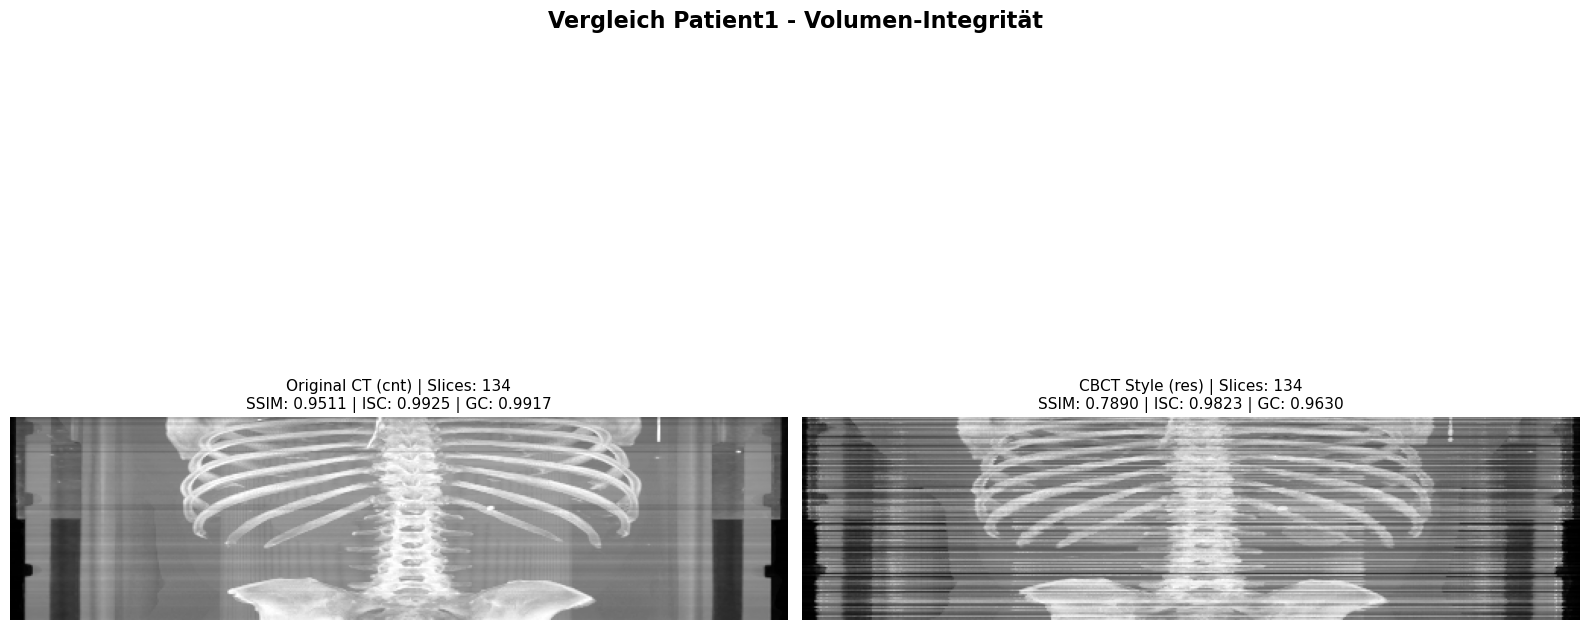

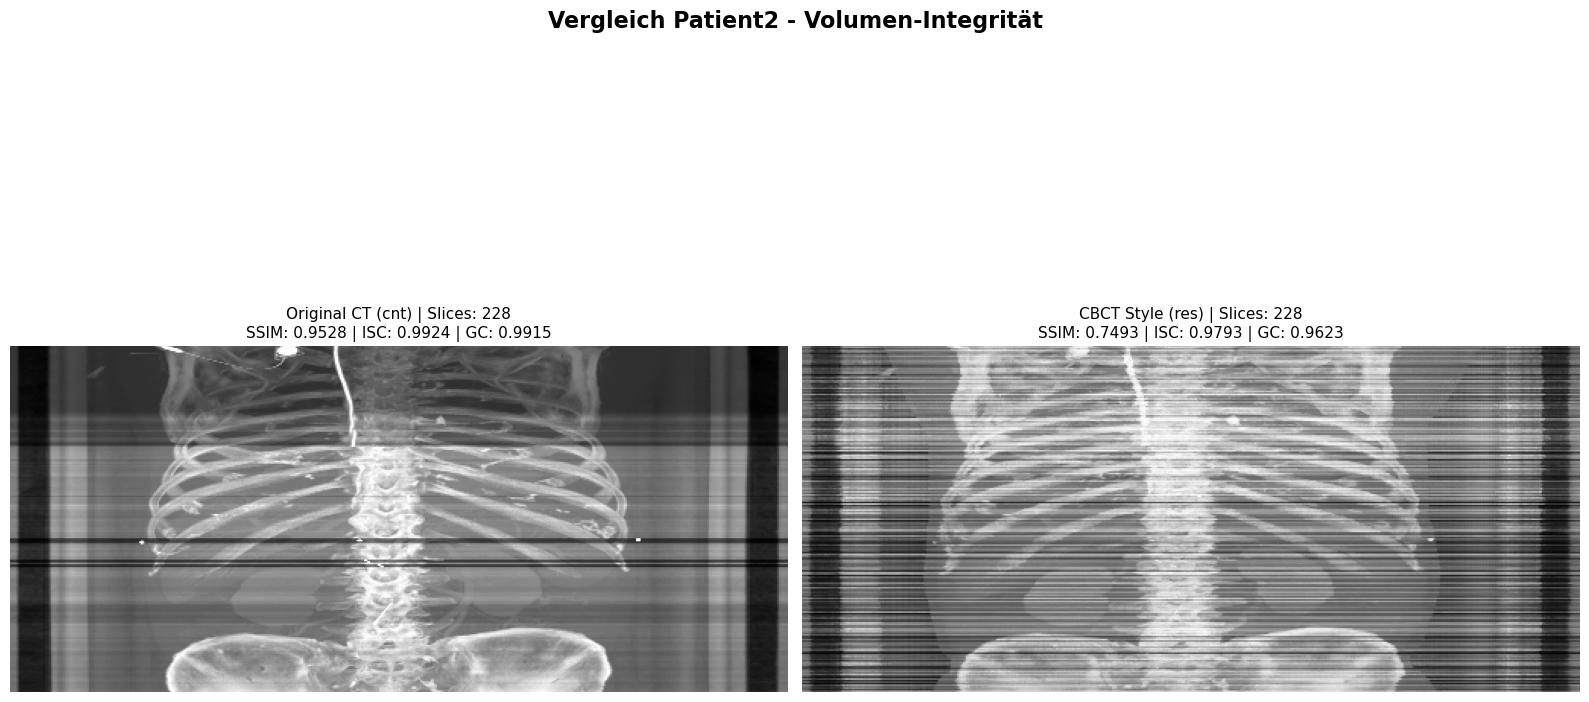

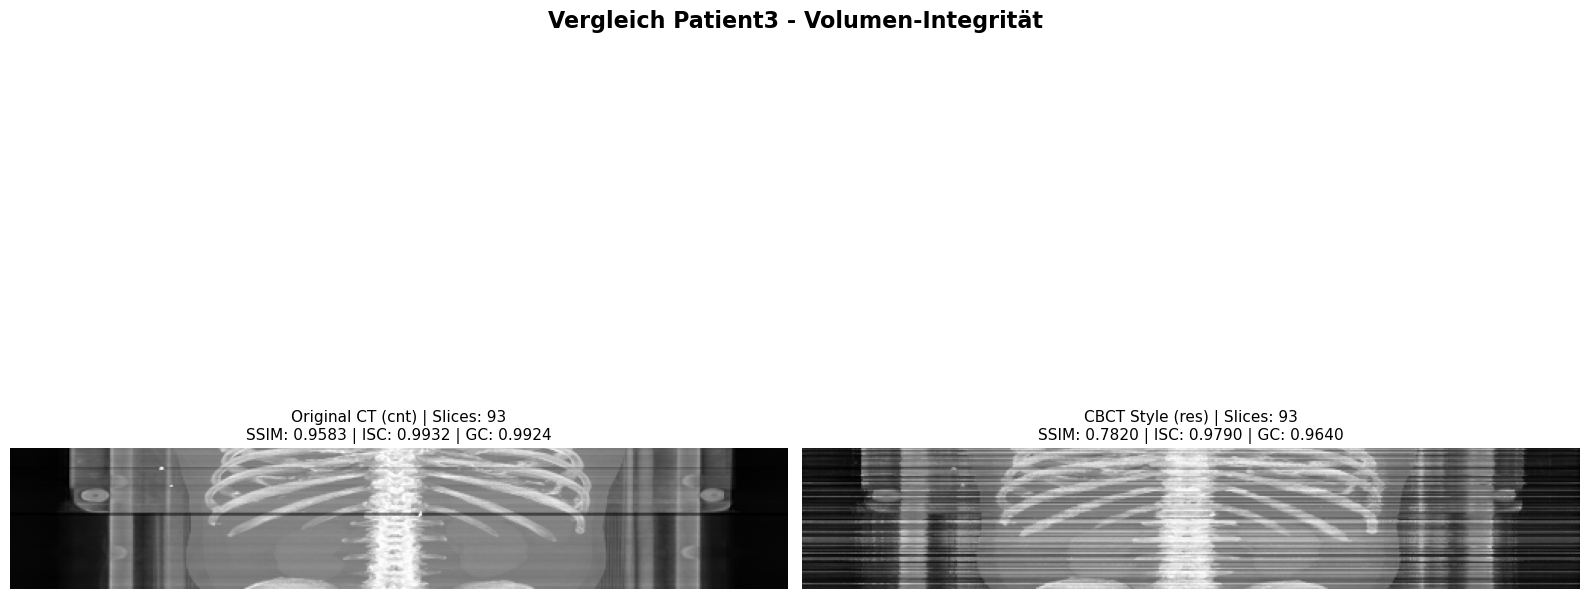

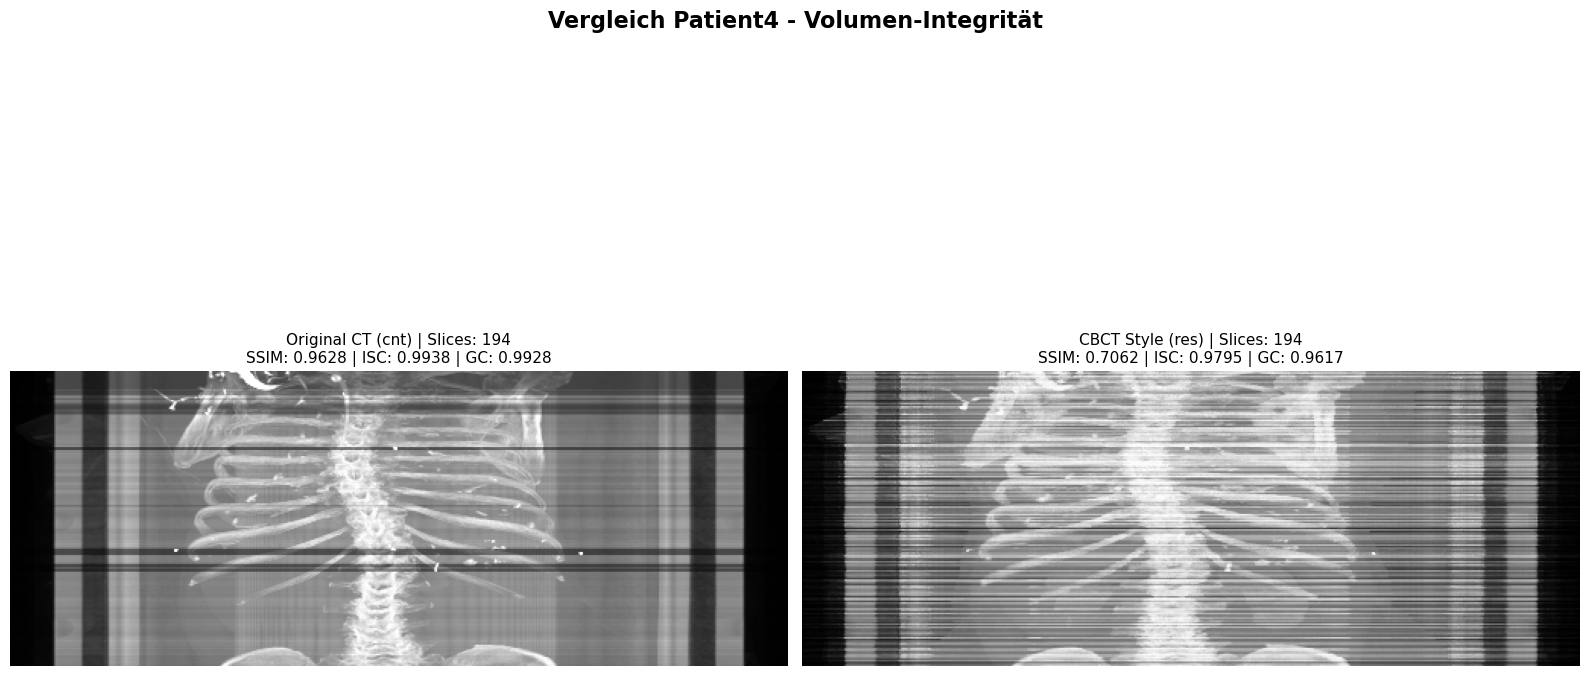

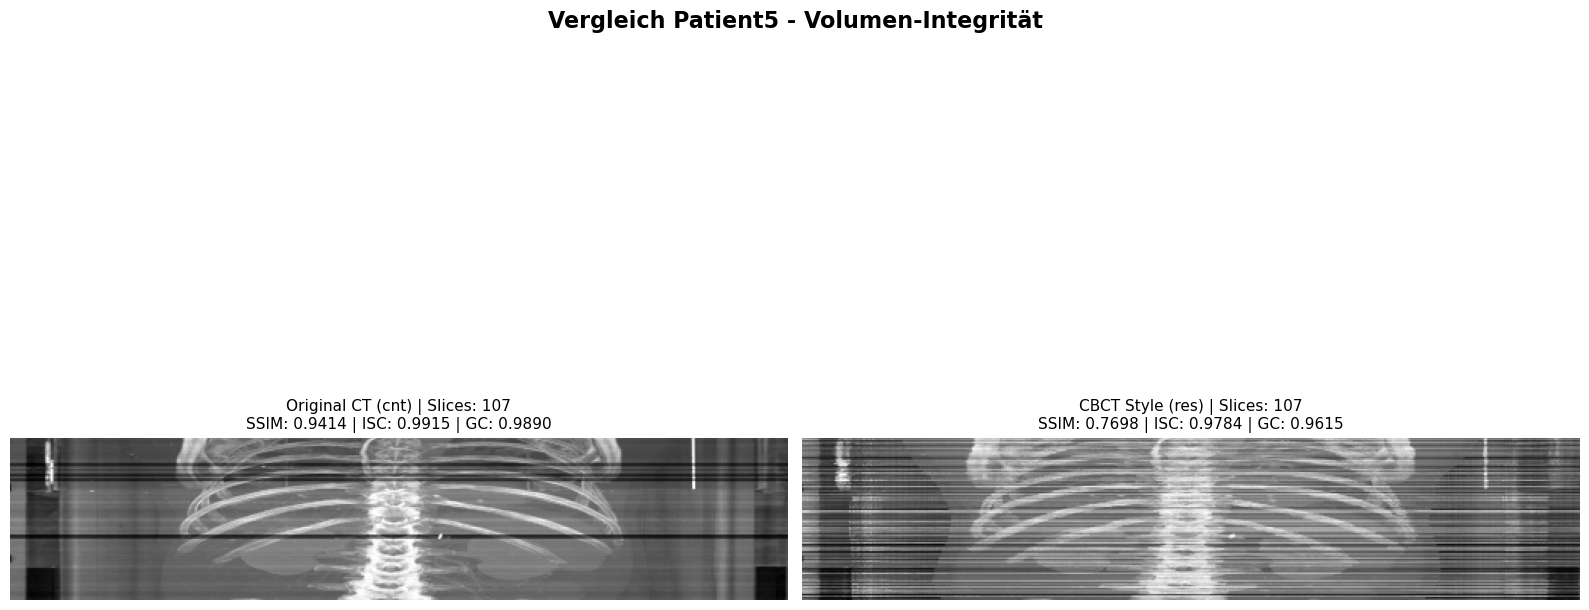

In [1]:
import pathlib
import pydicom
import cv2
import numpy as np
import re
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim

# --- HILFSFUNKTIONEN ---

def numerical_sort_key(path):
    numbers = re.findall(r'\d+', path.name)
    return int(numbers[-1]) if numbers else 0

def load_volume(folder_path):
    """Lädt DICOM oder PNG zu einem 3D-Volumen."""
    files = sorted([f for f in folder_path.glob("*") if f.suffix.lower() in ['.dcm', '.png']], key=numerical_sort_key)
    if not files: return None, None, None
    
    volume = []
    spacing, thickness = [1.0, 1.0], 1.0
    
    for i, f in enumerate(files):
        if f.suffix.lower() == '.dcm':
            ds = pydicom.dcmread(str(f))
            if i == 0:
                spacing = ds.PixelSpacing if 'PixelSpacing' in ds else [1.0, 1.0]
                thickness = ds.SliceThickness if 'SliceThickness' in ds else 1.0
            img = ds.pixel_array.astype(float)
            img = (img - np.min(img)) / (np.max(img) - np.min(img) + 1e-5) * 255
            volume.append(img.astype(np.uint8))
        else:
            img = cv2.imread(str(f), cv2.IMREAD_GRAYSCALE)
            if img is not None: volume.append(img)
            
    return np.array(volume), spacing, thickness

def get_projection_and_all_metrics(volume, z_factor):
    """Berechnet MIP und die drei Volumen-Metriken (SSIM, ISC, GC)."""
    if volume is None or len(volume) < 2: return None, 0.0, 0.0, 0.0
    
    ssim_list, isc_list, gc_list = [], [], []
    
    for i in range(len(volume) - 1):
        s1 = volume[i].astype(np.float32)
        s2 = volume[i+1].astype(np.float32)
        
        # 1. SSIM
        ssim_val = ssim(volume[i], volume[i+1], data_range=255)
        ssim_list.append(ssim_val)
        
        # 2. ISC (Pearson Korrelation)
        isc_val = np.corrcoef(s1.ravel(), s2.ravel())[0, 1]
        isc_list.append(isc_val)
        
        # 3. Gradient Continuity (Z-Gradient)
        # Wir messen die mittlere absolute Differenz zwischen den Schichten.
        # Ein Score von 1.0 bedeutet keine Änderung, niedrigere Werte bedeuten "Sprünge".
        diff = np.abs(s2 - s1)
        gc_val = 1.0 - (np.mean(diff) / 255.0)
        gc_list.append(gc_val)
    
    # MIP Projektion (Frontalansicht)
    mip = np.max(volume, axis=1)
    new_h = int(mip.shape[0] * z_factor)
    mip_resized = cv2.resize(mip, (mip.shape[1], new_h), interpolation=cv2.INTER_CUBIC)
    
    return mip_resized, np.mean(ssim_list), np.mean(isc_list), np.mean(gc_list)

# --- ANALYSE PATIENTEN 1, 2, 3 ---

HAUPT_ORDNER = "Patienten" # Pfad hier anpassen

for p_num in [1, 2, 3, 4, 5]:
    p_id = f"Patient{p_num}"
    p_path = pathlib.Path(HAUPT_ORDNER) / p_id
    
    if not p_path.exists(): continue

    vol_cnt, spacing, thick = load_volume(p_path / f"{p_id}_cnt")
    vol_res, _, _ = load_volume(p_path / f"{p_id}_res")
    
    if vol_cnt is None or vol_res is None or len(vol_cnt) < 2: continue
        
    z_factor = thick / spacing[0]
    
    # Metriken berechnen
    mip_c, ssim_c, isc_c, gc_c = get_projection_and_all_metrics(vol_cnt, z_factor)
    mip_r, ssim_r, isc_r, gc_r = get_projection_and_all_metrics(vol_res, z_factor)
    
    # VISUALISIERUNG
    fig, axes = plt.subplots(1, 2, figsize=(16, 10))
    fig.suptitle(f"Vergleich {p_id} - Volumen-Integrität", fontsize=16, fontweight='bold')

    # CT Darstellung
    axes[0].imshow(mip_c, cmap='gray')
    axes[0].set_title(
        f"Original CT (cnt) | Slices: {len(vol_cnt)}\n"
        f"SSIM: {ssim_c:.4f} | ISC: {isc_c:.4f} | GC: {gc_c:.4f}", fontsize=11
    )
    
    # CBCT Style Darstellung
    axes[1].imshow(mip_r, cmap='gray')
    axes[1].set_title(
        f"CBCT Style (res) | Slices: {len(vol_res)}\n"
        f"SSIM: {ssim_r:.4f} | ISC: {isc_r:.4f} | GC: {gc_r:.4f}", fontsize=11
    )

    for ax in axes: ax.axis('off')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()